# Taller 0: Modelo Centrado - Interpretación y Utilidad

En este taller exploraremos el modelo de regresión con variables centradas. Analizaremos cómo cambia la interpretación de los coeficientes al centrar las variables y las ventajas computacionales y analíticas de esta técnica.

## Objetivos de Aprendizaje
- Entender el modelo de regresión con variables centradas
- Analizar cómo cambia la interpretación de los coeficientes al centrar las variables
- Explorar las ventajas del centrado
- Implementar y comparar modelos con y sin centrado


In [1]:
# Importar librerías necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm

# Configuración para visualizaciones
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context('talk')
%matplotlib inline


## 📘 Teoría: Modelo Lineal Centrado

### ✨ Motivación
En modelos de regresión, el intercepto (\( \beta_0 \)) representa el valor esperado de \( Y \) cuando todas las variables predictoras son cero. Pero muchas veces, este valor no es interpretable o incluso es fuera del rango de los datos. Para solucionar esto, **centramos** las variables.

### 🔍 ¿Qué es centrar una variable?
Centrar una variable significa restarle su media:
\\[
X^*_i = X_i - \\bar{X}
\\]

Esto traslada el origen del eje \( X \) al valor medio de la muestra. La interpretación del intercepto ahora cambia: en vez de representar el valor de \( Y \) cuando \( X = 0 \), representa el valor esperado de \( Y \) cuando \( X = \\bar{X} \).

### 🧮 Comparación de modelos

- Modelo original:
\\[
Y_i = \\beta_0 + \\beta_1 X_i + \\varepsilon_i
\\]

- Modelo centrado:
\\[
Y_i = \\alpha + \\beta (X_i - \\bar{X}) + \\varepsilon_i
\\]

Relación entre parámetros:
\\[
\\alpha = \\beta_0 + \\beta_1 \\bar{X}
\\quad\\text{y}\\quad
\\beta = \\beta_1
\\]

### 📐 Interpretación
- **\\(\\beta\\)** sigue representando el cambio promedio en \( Y \) por unidad de cambio en \( X \), **no se ve afectado por el centrado**.
- **\\(\\alpha\\)** representa el valor esperado de \( Y \) cuando \( X = \\bar{X} \).

### 🛠️ Ventajas del centrado

1. ✅ Mejora la **interpretación** del intercepto en muchos contextos.
2. ✅ Facilita el análisis de **interacciones** y **términos polinómicos**.
3. ✅ Ayuda a reducir **multicolinealidad** entre \( X \) y \( X^2 \), por ejemplo.
4. ✅ Mejora la **estabilidad numérica** en métodos computacionales iterativos (como descenso de gradiente).
5. ✅ Puede mejorar la **convergencia** de algunos algoritmos cuando se trabaja con escalas muy dispares.

### 📌 Nota
El centrado **no cambia** el ajuste del modelo ni las predicciones. Solamente modifica la representación de los parámetros.


## Definición del Modelo Centrado

En un modelo de regresión estándar, tenemos:

$$y_i = \beta_0 + \beta_1 x_{i1} + \beta_2 x_{i2} + ... + \beta_p x_{ip} + \varepsilon_i$$

Al centrar las variables, trabajamos con:

$$y_i - \bar{y} = \beta_1 (x_{i1} - \bar{x}_1) + \beta_2 (x_{i2} - \bar{x}_2) + ... + \beta_p (x_{ip} - \bar{x}_p) + \varepsilon_i$$

O de forma equivalente:

$$y_i = \beta_0^* + \beta_1 (x_{i1} - \bar{x}_1) + \beta_2 (x_{i2} - \bar{x}_2) + ... + \beta_p (x_{ip} - \bar{x}_p) + \varepsilon_i$$

Donde $\beta_0^* = \bar{y} - \sum_{j=1}^{p} \beta_j \bar{x}_j$ y los coeficientes $\beta_j$ para $j \geq 1$ son idénticos en ambos modelos.

## Cambios en la Interpretación de los Coeficientes

### En el Modelo Original:
- $\beta_0$: Valor esperado de $y$ cuando todas las variables independientes son 0
- $\beta_j$: Cambio esperado en $y$ cuando $x_j$ aumenta en una unidad, manteniendo las demás variables constantes

### En el Modelo Centrado:
- $\beta_0^*$: Valor esperado de $y$ cuando todas las variables independientes están en sus valores medios
- $\beta_j$: Cambio esperado en $y$ cuando $x_j$ aumenta en una unidad desde su media, manteniendo las demás variables en sus valores medios


# Demostración Matricial General: Equivalencia de Coeficientes

Vamos a demostrar matemáticamente que los coeficientes de pendiente (β₁, β₂, ..., βₚ) son idénticos en el modelo original y en el modelo centrado, para el caso general de regresión lineal múltiple.

## Notación y Definiciones

Para establecer la notación:

- $X$ es la matriz de diseño original de dimensiones $n \times (p+1)$, donde la primera columna es un vector de unos
- $y$ es el vector de respuestas de dimensión $n \times 1$
- $\beta = (\beta_0, \beta_1, \ldots, \beta_p)^T$ es el vector de coeficientes del modelo original
- $\beta_c = (\beta_{c0}, \beta_{c1}, \ldots, \beta_{cp})^T$ es el vector de coeficientes del modelo centrado

Definamos ahora la matriz de centrado $C$ de dimensión $n \times n$:

$$C = I_n - \frac{1}{n}\mathbf{1}_n\mathbf{1}_n^T$$

donde $I_n$ es la matriz identidad de orden $n$ y $\mathbf{1}_n$ es un vector de unos de longitud $n$.

La matriz $C$ tiene las siguientes propiedades:
- $C$ es simétrica: $C^T = C$
- $C$ es idempotente: $C^2 = C$
- $C\mathbf{1}_n = \mathbf{0}_n$ (anula cualquier vector constante)
- Para cualquier vector $v$, $Cv$ es el vector centrado (con media cero)

## Matrices del Modelo Centrado

Podemos representar la matriz de diseño del modelo centrado $X_c$ como:

$$X_c = \begin{bmatrix} \mathbf{1}_n & CX_{-0} \end{bmatrix}$$

donde $X_{-0}$ es la matriz $X$ sin la primera columna (los predictores sin el intercepto).

Esto significa que mantenemos la columna de unos para el intercepto, pero centramos todas las otras columnas de predictores.

## Derivación de los Estimadores

### Modelo Original
El estimador de mínimos cuadrados ordinarios (OLS) para $\beta$ es:

$$\hat{\beta} = (X^TX)^{-1}X^Ty$$

### Modelo Centrado
El estimador OLS para $\beta_c$ es:

$$\hat{\beta}_c = (X_c^TX_c)^{-1}X_c^Ty$$

## Particionamiento de la Matriz X

Para facilitar la demostración, particionemos $X$ como:

$$X = \begin{bmatrix} \mathbf{1}_n & X_{-0} \end{bmatrix}$$

Donde $\mathbf{1}_n$ es la columna de unos y $X_{-0}$ contiene todas las demás columnas.

Similarmente, particionamos $\beta$ como:

$$\beta = \begin{bmatrix} \beta_0 \\ \beta_{-0} \end{bmatrix}$$

donde $\beta_0$ es el intercepto y $\beta_{-0}$ es el vector de coeficientes de pendiente.

## Demostración

Primero, notemos que:

$$X_c^TX_c = \begin{bmatrix} 
n & \mathbf{0}^T \\
\mathbf{0} & (CX_{-0})^T(CX_{-0})
\end{bmatrix}$$

Esto es porque $\mathbf{1}_n^TCX_{-0} = \mathbf{0}^T$ debido a que $C\mathbf{1}_n = \mathbf{0}_n$.

Además, $(CX_{-0})^T(CX_{-0}) = X_{-0}^TC^TCX_{-0} = X_{-0}^TCX_{-0}$ ya que $C^T = C$ y $C^2 = C$.

También:

$$X_c^Ty = \begin{bmatrix} 
\mathbf{1}_n^Ty \\
(CX_{-0})^Ty
\end{bmatrix} = \begin{bmatrix} 
n\bar{y} \\
X_{-0}^TCy
\end{bmatrix}$$

La inversión de $X_c^TX_c$ es:

$$
(X_c^TX_c)^{-1} = \begin{bmatrix} 
\frac{1}{n} & \mathbf{0}^T \\
\mathbf{0} & (X_{-0}^TCX_{-0})^{-1}
\end{bmatrix}
$$

Por lo tanto:

$$
\hat{\beta}_c = \begin{bmatrix} 
\frac{1}{n} \cdot n\bar{y} \\
(X_{-0}^TCX_{-0})^{-1}X_{-0}^TCy
\end{bmatrix} = \begin{bmatrix} 
\bar{y} \\
(X_{-0}^TCX_{-0})^{-1}X_{-0}^TCy
\end{bmatrix}
$$

Ahora, para el modelo original, si usamos las técnicas de inversión de matrices por bloques en $(X^TX)^{-1}$, podemos demostrar que los coeficientes de pendiente son:

$$\hat{\beta}_{-0} = (X_{-0}^TMX_{-0})^{-1}X_{-0}^TMy$$

donde $M = I_n - \frac{1}{n}\mathbf{1}_n\mathbf{1}_n^T = C$ es exactamente nuestra matriz de centrado.

Por lo tanto:

$$\hat{\beta}_{-0} = (X_{-0}^TCX_{-0})^{-1}X_{-0}^TCy = \hat{\beta}_{c,-0}$$

Esto demuestra que los coeficientes de pendiente del modelo original $\hat{\beta}_{-0}$ son idénticos a los coeficientes de pendiente del modelo centrado $\hat{\beta}_{c,-0}$.

## Relación Entre Interceptos

Para completar, la relación entre los interceptos es:

$$\hat{\beta}_0 = \hat{\beta}_{c0} - \hat{\beta}_{-0}^T\bar{X}_{-0}$$

donde $\bar{X}_{-0}$ es el vector de medias de las columnas de $X_{-0}$.

Esta relación se puede verificar sustituyendo las estimaciones en la ecuación del modelo y evaluando en el punto medio de los datos.


# 🧪 Implementación del Modelo Centrado

Vamos a comparar dos modelos de regresión lineal:

1. El modelo original: donde usamos la variable predictora \( X \) tal como está.
2. El modelo centrado: donde usamos la variable centrada \( X_c = X - \\bar{X} \).

Verificaremos que:

- El coeficiente de pendiente \( \\beta \) se mantiene igual.
- El intercepto cambia y adquiere una nueva interpretación.
- Las predicciones del modelo **no cambian**.

También visualizaremos las diferencias en las rectas ajustadas para mejorar la interpretación.


In [2]:

def centrar_variables(X, return_means=False):
    """
    Centra las variables predictoras restando la media de cada columna.

    Parámetros:
    -----------
    X : array-like o DataFrame
        Variables predictoras a centrar
    return_means : bool, opcional
        Si es True, devuelve también las medias utilizadas para centrar

    Retorna:
    --------
    X_centrado : array o DataFrame
        Variables predictoras centradas
    means : Series o array (opcional)
        Medias de cada columna
    """
    if isinstance(X, pd.DataFrame):
        means = X.mean()
        X_centrado = X - means
    else:
        X = np.asarray(X)
        means = np.mean(X, axis=0)
        X_centrado = X - means

    if return_means:
        return X_centrado, means
    return X_centrado

def ajustar_modelo_original(X, y):
    """
    Ajusta un modelo de regresión utilizando las variables originales.

    Parámetros:
    -----------
    X : array-like o DataFrame
        Variables predictoras
    y : array-like o Series
        Variable respuesta

    Retorna:
    --------
    result : objeto ResultadosRegresion
        Resultados de la regresión con statsmodels
    """
    X_sm = sm.add_constant(X)
    return sm.OLS(y, X_sm).fit()

def ajustar_modelo_centrado(X, y):
    """
    Ajusta un modelo de regresión utilizando variables centradas.

    Parámetros:
    -----------
    X : array-like o DataFrame
        Variables predictoras
    y : array-like o Series
        Variable respuesta

    Retorna:
    --------
    result : objeto ResultadosRegresion
        Resultados de la regresión con statsmodels
    means_X : Series o array
        Medias de las variables predictoras
    mean_y : float
        Media de la variable respuesta
    """
    # Centrar predictores
    X_centrado, means_X = centrar_variables(X, return_means=True)

    # Obtener media de y (aunque no la usamos para centrar en el modelo)
    if isinstance(y, pd.Series):
        mean_y = y.mean()
    else:
        mean_y = np.mean(y)

    # Ajustar modelo con X centrado pero y original
    X_sm = sm.add_constant(X_centrado)
    modelo = sm.OLS(y, X_sm).fit()

    return modelo, means_X, mean_y

def convertir_coef_centrados_a_originales(modelo_centrado, means_X):
    """
    Convierte los coeficientes del modelo centrado a la escala original.

    Parámetros:
    -----------
    modelo_centrado : objeto ResultadosRegresion
        Modelo ajustado con variables centradas
    means_X : Series o array
        Medias de las variables predictoras

    Retorna:
    --------
    coef_originales : array
        Coeficientes en la escala original
    """
    # Obtener coeficientes del modelo centrado
    coef_centrados = modelo_centrado.params

    # Crear array para los coeficientes originales
    coef_originales = np.zeros_like(coef_centrados)

    # El intercepto original es el centrado menos la suma de (beta_j * mean_X_j)
    intercepto = coef_centrados[0]
    for j in range(1, len(coef_centrados)):
        intercepto -= coef_centrados[j] * means_X[j-1]

    coef_originales[0] = intercepto
    coef_originales[1:] = coef_centrados[1:]

    return coef_originales

def comparar_coeficientes(modelo_original, modelo_centrado, means_X):
    """
    Compara los coeficientes de los modelos original y centrado.

    Parámetros:
    -----------
    modelo_original : objeto ResultadosRegresion
        Modelo ajustado con variables originales
    modelo_centrado : objeto ResultadosRegresion
        Modelo ajustado con variables centradas
    means_X : Series o array
        Medias de las variables predictoras

    Retorna:
    --------
    None
        Imprime una comparación de los coeficientes
    """
    coef_originales = modelo_original.params
    coef_centrados = modelo_centrado.params
    coef_convertidos = convertir_coef_centrados_a_originales(modelo_centrado, means_X)

    print("Comparación de coeficientes:")
    print("-" * 50)
    print(f"β₀ (Intercepto):")
    print(f"  Modelo original:     {coef_originales[0]:.6f}")
    print(f"  Convertido de centrado: {coef_convertidos[0]:.6f}")
    print(f"  Diferencia absoluta: {abs(coef_originales[0] - coef_convertidos[0]):.6f}")
    print("-" * 50)

    for i in range(1, len(coef_originales)):
        print(f"β{i}:")
        print(f"  Modelo original:   {coef_originales[i]:.6f}")
        print(f"  Modelo centrado:   {coef_centrados[i]:.6f}")
        print(f"  Diferencia absoluta: {abs(coef_originales[i] - coef_centrados[i]):.6f}")
        print("-" * 50)


# 🔧 Generación de Datos para Ejemplos

Vamos a simular datos para ilustrar cómo funciona la regresión lineal con y sin centrado. 

### 📊 Especificaciones:
- Generamos 50 observaciones equiespaciadas de una variable \( X \) entre 0 y 10.
- El valor de \( Y \) está dado por:
\\[
Y = 3 + 2X + \\varepsilon, \\quad \\varepsilon \\sim \\mathcal{N}(0, 2^2)
\\]
- Fijamos la semilla para asegurar reproducibilidad.

Este conjunto nos permitirá comparar de manera controlada los efectos del centrado.


Estadísticas descriptivas de las variables generadas:
               X1          X2           Y
count  100.000000  100.000000  100.000000
mean     9.792307   20.066914    1.199826
std      1.816337    2.861007    4.104632
min      4.760510   14.243686  -11.376426
25%      8.798189   17.583018   -1.260414
50%      9.746087   20.252322    1.955126
75%     10.811904   21.614511    3.831840
max     13.704556   28.160507   10.089841


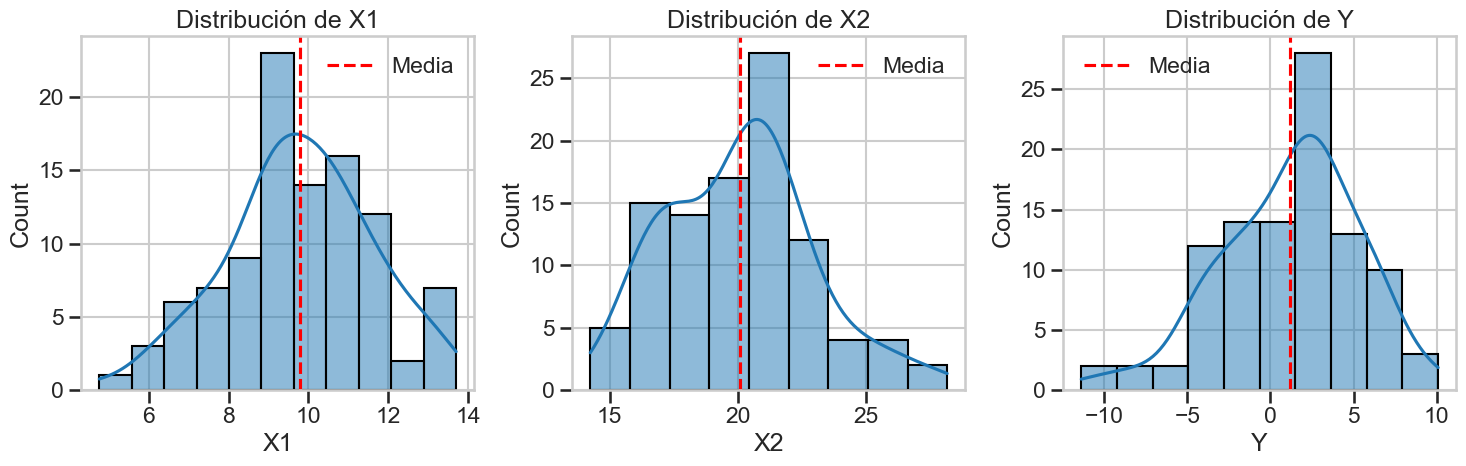

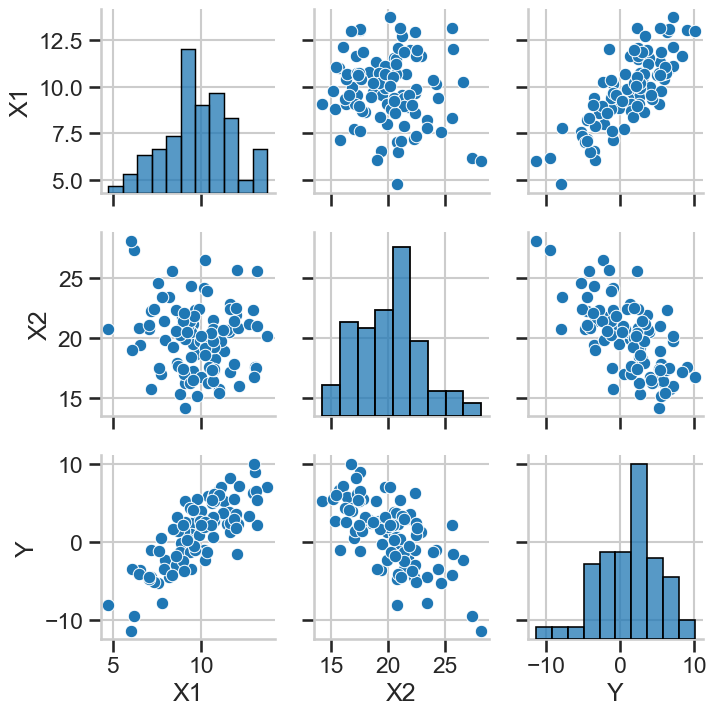

In [3]:

def generar_datos_simulados(n=100, beta_true=[2.5, 1.5, -0.8], seed=42, escala_x=10):
    """
    Genera datos sintéticos para regresión lineal múltiple.

    Parámetros:
    -----------
    n : int
        Número de observaciones
    beta_true : list
        Coeficientes reales [intercepto, beta_1, beta_2]
    seed : int
        Semilla para reproducibilidad
    escala_x : float
        Factor de escala para las variables predictoras

    Retorna:
    --------
    X : DataFrame
        Variables predictoras
    y : Series
        Variable respuesta
    """
    np.random.seed(seed)

    # Generar predictores 
    X1 = np.random.normal(escala_x, 2, n)      # Media = 10, std = 2
    X2 = np.random.normal(escala_x * 2, 3, n)  # Media = 20, std = 3

    # Convertir a DataFrame para mejor manejo
    X = pd.DataFrame({'X1': X1, 'X2': X2})

    # Generar variable respuesta
    intercepto = beta_true[0]
    error = np.random.normal(0, 1, n)  # Error aleatorio

    y = intercepto + beta_true[1] * X['X1'] + beta_true[2] * X['X2'] + error
    y = pd.Series(y, name='Y')

    return X, y

# Generar datos para nuestro ejemplo
X, y = generar_datos_simulados(n=100)

# Mostrar estadísticas descriptivas
print("Estadísticas descriptivas de las variables generadas:")
descripcion = pd.concat([X, y], axis=1).describe()
print(descripcion)

# Visualizar la distribución de las variables
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.histplot(X['X1'], kde=True, ax=axes[0])
axes[0].set_title('Distribución de X1')
axes[0].axvline(X['X1'].mean(), color='r', linestyle='--', label='Media')
axes[0].legend()

sns.histplot(X['X2'], kde=True, ax=axes[1])
axes[1].set_title('Distribución de X2')
axes[1].axvline(X['X2'].mean(), color='r', linestyle='--', label='Media')
axes[1].legend()

sns.histplot(y, kde=True, ax=axes[2])
axes[2].set_title('Distribución de Y')
axes[2].axvline(y.mean(), color='r', linestyle='--', label='Media')
axes[2].legend()

plt.tight_layout()
plt.show()

# Crear una matriz de dispersión para visualizar relaciones
scatter_plot = sns.pairplot(pd.concat([X, y], axis=1))
plt.tight_layout()
plt.show()


# Ejemplos Prácticos: Comparación de Modelos Original y Centrado

A continuación, implementaremos y compararemos modelos con y sin centrado usando los datos generados.


MODELO CON VARIABLES ORIGINALES
                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.933
Model:                            OLS   Adj. R-squared:                  0.931
Method:                 Least Squares   F-statistic:                     672.9
Date:                Wed, 02 Apr 2025   Prob (F-statistic):           1.37e-57
Time:                        13:49:28   Log-Likelihood:                -147.62
No. Observations:                 100   AIC:                             301.2
Df Residuals:                      97   BIC:                             309.1
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.540

C:\Users\cizai\AppData\Local\Temp\ipykernel_23368\3604493489.py:108: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercepto = coef_centrados[0]
C:\Users\cizai\AppData\Local\Temp\ipykernel_23368\3604493489.py:110: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercepto -= coef_centrados[j] * means_X[j-1]
C:\Users\cizai\AppData\Local\Temp\ipykernel_23368\3604493489.py:142: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"  Mod

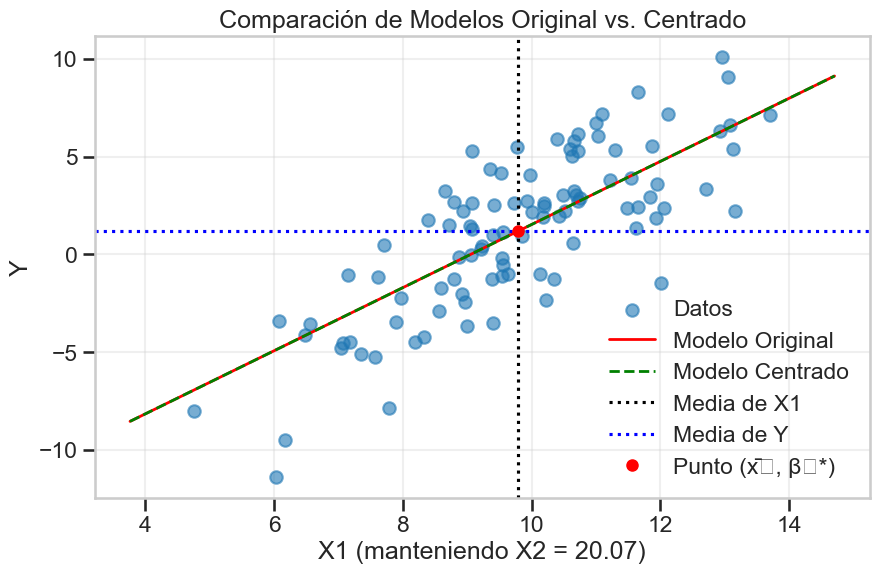

In [4]:

# Ajustar modelo con variables originales
modelo_original = ajustar_modelo_original(X, y)

# Ajustar modelo con variables centradas
modelo_centrado, means_X, mean_y = ajustar_modelo_centrado(X, y)

# Mostrar resumen de los modelos
print("="*80)
print("MODELO CON VARIABLES ORIGINALES")
print("="*80)
print(modelo_original.summary())

print("\n")
print("="*80)
print("MODELO CON VARIABLES CENTRADAS")
print("="*80)
print(modelo_centrado.summary())

# Comparar los coeficientes de los modelos
comparar_coeficientes(modelo_original, modelo_centrado, means_X)

# Verificar matemáticamente la relación entre los interceptos
print("\nVerificación matemática de la relación entre interceptos:")
b0_original = modelo_original.params[0]
b1_original = modelo_original.params[1]
b2_original = modelo_original.params[2]

b0_centrado = modelo_centrado.params[0]

# Calcular intercepto original a partir del centrado y las medias
b0_calculado = b0_centrado - b1_original * means_X[0] - b2_original * means_X[1]

print(f"β₀ (original): {b0_original:.6f}")
print(f"β₀ (calculado como β₀* - β₁·x̄₁ - β₂·x̄₂): {b0_calculado:.6f}")
print(f"Diferencia: {abs(b0_original - b0_calculado):.6f}")

# Visualizar las diferentes rectas de regresión para X1 (manteniendo X2 constante)
plt.figure(figsize=(10, 6))

# Rango de valores para X1
x1_range = np.linspace(X['X1'].min() - 1, X['X1'].max() + 1, 100)

# Calcular los valores predichos para el modelo original
x2_media = X['X2'].mean()  # Valor fijo para X2
y_pred_original = modelo_original.params[0] + modelo_original.params[1] * x1_range + modelo_original.params[2] * x2_media

# Calcular los valores predichos para el modelo centrado
y_pred_centrado = modelo_centrado.params[0] + modelo_centrado.params[1] * (x1_range - means_X[0]) + modelo_centrado.params[2] * (x2_media - means_X[1])

# Graficar los datos originales (proyectados en el plano X1-Y para X2=media)
plt.scatter(X['X1'], y, alpha=0.6, label='Datos')

# Graficar las líneas de regresión
plt.plot(x1_range, y_pred_original, 'r-', linewidth=2, label='Modelo Original')
plt.plot(x1_range, y_pred_centrado, 'g--', linewidth=2, label='Modelo Centrado')

# Marcar las medias
plt.axvline(x=means_X[0], color='k', linestyle=':', label='Media de X1')
plt.axhline(y=mean_y, color='b', linestyle=':', label='Media de Y')
plt.plot(means_X[0], modelo_centrado.params[0], 'ro', markersize=8, label='Punto (x̄₁, β₀*)')

plt.title('Comparación de Modelos Original vs. Centrado')
plt.xlabel('X1 (manteniendo X2 = {:.2f})'.format(x2_media))
plt.ylabel('Y')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


# Interpretación de Coeficientes en Modelos Centrados vs. Originales

Comparemos la interpretación de los coeficientes en cada modelo:

## 1. Intercepto (β₀)

**Modelo Original:**
- El intercepto (β₀) representa el valor esperado de Y cuando X1 = 0 y X2 = 0
- A menudo, X1 = 0 y X2 = 0 puede estar fuera del rango de datos observados
- La interpretación puede no ser prácticamente significativa

**Modelo Centrado:**
- El intercepto (β₀*) representa el valor esperado de Y cuando X1 = X̄₁ y X2 = X̄₂
- Es el valor esperado de Y en el punto "promedio" de los datos
- La interpretación tiene mayor relevancia práctica

## 2. Coeficientes de Pendiente (β₁, β₂)

**Modelo Original y Centrado:**
- Los coeficientes de pendiente (β₁, β₂) son idénticos en ambos modelos
- Representan el cambio esperado en Y cuando la variable correspondiente aumenta en una unidad, manteniendo las demás constantes

## 3. Relación Matemática

La relación matemática entre los interceptos es:

$$\beta_0 = \beta_0^* - \beta_1 \bar{X}_1 - \beta_2 \bar{X}_2$$

Como pudimos verificar con nuestros datos, esta relación se cumple exactamente.


# Ventajas del Centrado de Variables

El centrado de variables ofrece varias ventajas en la modelación:

## 1. Interpretación más Significativa del Intercepto

- El intercepto en un modelo centrado representa el valor esperado de la variable respuesta cuando todas las variables predictoras están en sus valores medios.
- Esta interpretación suele ser más útil que la del modelo original, especialmente cuando el valor de cero para las variables predictoras está fuera del rango de los datos o no tiene sentido práctico.

## 2. Estabilidad Numérica Mejorada

- El centrado puede mejorar la estabilidad numérica del proceso de estimación, especialmente cuando las variables tienen medias muy alejadas de cero.
- Esto es particularmente relevante en cálculos computacionales que involucran inversión de matrices.

## 3. Facilita la Comprensión y Presentación de Resultados

- Los efectos centrados son más fáciles de comunicar y entender en presentaciones y reportes.
- El intercepto del modelo centrado proporciona un "punto de referencia" natural en el centro de los datos.

## 4. Base para Modelos más Complejos

- El centrado es un primer paso importante antes de introducir términos de interacción o polinómicos en modelos más avanzados.
- Facilita la extensión del modelo lineal simple a modelos más complejos.


# Ejercicios

A continuación se presentan varios ejercicios para practicar los conceptos aprendidos sobre el modelo centrado.

### Ejercicio 1
Utiliza el siguiente código para generar un conjunto de datos donde las variables X1 y X2 tienen medias muy alejadas de cero:

```python
np.random.seed(123)
X1 = np.random.normal(100, 5, 50)  # Media = 100
X2 = np.random.normal(200, 10, 50)  # Media = 200
X = pd.DataFrame({'X1': X1, 'X2': X2})
y = 5 + 2 * X1 - 3 * X2 + np.random.normal(0, 10, 50)
```

1. Ajusta un modelo de regresión usando las variables originales.
2. Ajusta un modelo usando variables centradas.
3. Verifica que los coeficientes de pendiente son iguales en ambos modelos.
4. Calcula manualmente el intercepto del modelo original a partir del intercepto del modelo centrado y comprueba que coincide.

### Ejercicio 2
Usando los mismos datos del Ejercicio 1:

1. Calcula las predicciones para 3 observaciones utilizando ambos modelos (original y centrado).
2. Verifica que ambos modelos producen exactamente las mismas predicciones.
3. Visualiza las rectas de regresión para ambos modelos en un gráfico 2D (fijando X2 en su valor medio).

### Ejercicio 3
Crea un conjunto de datos donde el valor X = 0 esté muy alejado del rango de los datos:

```python
np.random.seed(456)
X = np.random.uniform(50, 60, 30)  # Valores entre 50 y 60
y = 10 + 2 * X + np.random.normal(0, 5, 30)
```

1. Ajusta un modelo de regresión simple usando X original.
2. Ajusta un modelo usando X centrado.
3. Compara la interpretación del intercepto en ambos modelos.
4. ¿Cuál de los dos interceptos tiene una interpretación más útil para estos datos? ¿Por qué?


# Conclusiones

En este taller hemos explorado el modelo de regresión con variables centradas y sus propiedades:

1. **Equivalencia matemática**: 
   - Hemos demostrado que el modelo centrado y el modelo original son matemáticamente equivalentes y producen las mismas predicciones.
   - Los coeficientes de pendiente (β₁, β₂, ..., βₚ) son idénticos en ambos modelos.
   - El intercepto del modelo original se puede calcular a partir del intercepto del modelo centrado usando la fórmula β₀ = β₀* - β₁·x̄₁ - β₂·x̄₂ - ... - βₚ·x̄ₚ.

2. **Interpretación mejorada**:
   - El intercepto en un modelo centrado tiene una interpretación más natural y útil, representando el valor esperado de Y cuando todas las variables están en sus valores medios.
   - Esta interpretación es especialmente útil cuando el valor 0 para las variables predictoras está fuera del rango de los datos o no tiene sentido práctico.

3. **Beneficios prácticos**:
   - El centrado de variables facilita la comprensión y comunicación de los resultados del modelo.
   - Proporciona un punto de referencia natural (el centro de los datos) para interpretar el intercepto.
   - Mejora la estabilidad numérica en algunos casos, especialmente cuando las variables tienen medias muy alejadas de cero.

Es importante destacar que el centrado de variables es una transformación simple pero útil que no afecta la capacidad predictiva del modelo ni cambia la interpretación de los coeficientes de pendiente. Sin embargo, proporciona una interpretación más significativa del intercepto y sienta las bases para extensiones más complejas del modelo lineal.


# Referencias

1. Afshartous, D., & Preston, R. A. (2011). Key results of interaction models with centering. *Journal of Statistics Education, 19*(3).

2. Aiken, L. S., & West, S. G. (1991). *Multiple regression: Testing and interpreting interactions*. Sage Publications.

3. Kutner, M. H., Nachtsheim, C. J., Neter, J., & Li, W. (2005). *Applied linear statistical models* (5th ed.). McGraw-Hill/Irwin.
